# BIRCH - Instacart (simple)


Evaluación del número de clusters y ajuste final del modelo. El `k` recomendado se selecciona mediante el mayor coeficiente silhouette.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from modeling_functions import (
    birch_metrics,
    plot_clustering_metrics,
    analyze_clusters,
    fit_clustering_model,
    save_clustering_metrics,
)
import pandas as pd

## Carga y preparación de los datos


In [2]:
df_scaled = pd.read_csv("../../../scaled_data/instacart_scaled.csv")
df_original = pd.read_csv("../../../simple_datasets/instacart_model_simple.csv")

# Conserva en el escalado solo las variables incluidas en esta versión del dataset.
columnas_modelo = [col for col in df_original.columns if col in df_scaled.columns]
df_scaled_modelo = df_scaled[columnas_modelo].copy()
X = df_scaled_modelo.drop(columns=["user_id"], errors="ignore")

print(f"Observaciones: {X.shape[0]:,}")
print(f"Variables de clustering: {X.shape[1]}")
display(X.head())

Observaciones: 206,209
Variables de clustering: 3


,recency,frequency,avg_basket_size
0,-0.286895,-0.070348,-0.578158
1,1.212334,0.316791,0.820566
2,-0.568000,0.138171,-0.236083
3,1.212334,-0.826933,-1.313020
4,-1.036509,-1.054508,0.139108


## Evaluación del número de clusters


In [3]:
resultados_birch = birch_metrics(X)
display(resultados_birch)

c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(
c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(
c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(
c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(
c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but M

,k,silhouette,calinski_harabasz,davies_bouldin,n_clusters_found,tiempo_segundos
0,2,0.208966,57577.628523,1.792867,2,4.396216
1,3,0.252359,83248.661120,1.320053,3,2.842446
2,4,0.270017,88279.309842,1.117062,4,2.844627
3,5,0.212928,63432.427871,1.333994,5,2.843772
4,6,0.245828,79110.273297,1.121164,6,2.835760
5,7,0.231289,68196.044525,1.153977,7,2.863939
6,8,0.266408,83246.626760,1.041322,8,2.834646
7,9,0.257398,80541.412457,1.055732,9,2.844717
8,10,0.255029,76571.971734,1.075224,10,2.829613


In [ ]:
tabla_metricas = save_clustering_metrics(
    resultados_birch,
    model_name="birch",
    dataset_name="instacart",
    dataset_version="simple",
)

print("Métricas consolidadas en ../../../results/clustering_metrics.csv")
display(tabla_metricas)

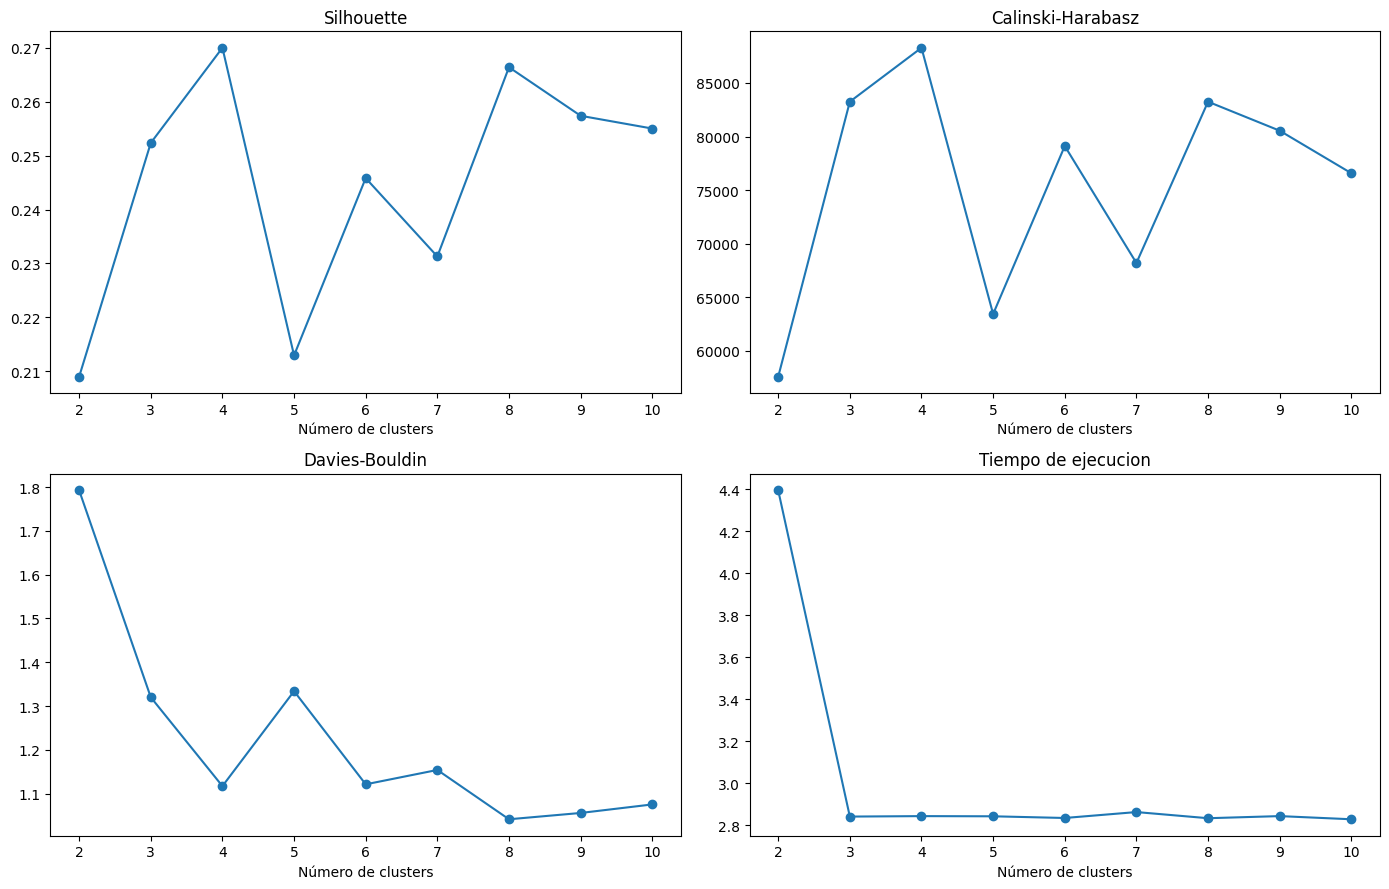

In [4]:
plot_clustering_metrics(
    resultados_birch,
    fourth_metric="tiempo_segundos",
    fourth_title="Tiempo de ejecución",
)

## Ajuste final y perfil de los clusters


In [ ]:
modelo, labels = fit_clustering_model(
    model_name="birch",
    k=4,
    X=X,
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels=labels,
    df_scaled=df_scaled_modelo,
    df_original=df_original,
    id_col="user_id",
)

print("Tamaño de los clusters:")
display(cluster_sizes)
print("Porcentaje de clientes:")
display(porcentajes)
print("Perfil medio de los clusters:")
display(perfil_clusters)

Tamaño de los clusters:


c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(


cluster
0    61313
1    62471
2    46652
3    35773
Name: count, dtype: int64

Porcentaje de clientes:


cluster
0    29.73
1    30.29
2    22.62
3    17.35
Name: proportion, dtype: float64

Perfil medio de los clusters:


,recency,frequency,avg_basket_size
cluster,,,
0,28.023,7.863,6.446
1,17.750,9.841,16.285
2,8.773,38.663,9.505
3,7.882,8.787,5.482


- Cluster 0 - Clientes poco recientes de cesta pequeña (29,73%): presentan la mayor recencia, baja frecuencia y el segundo menor tamaño de cesta.
- Cluster 1 - Clientes ocasionales de cesta grande (30,29%): compran con poca frecuencia y una recencia intermedia, pero realizan las cestas más grandes.
- Cluster 2 - Clientes frecuentes y activos (22,62%): destacan por una frecuencia muy elevada, baja recencia y cestas de tamaño medio.
- Cluster 3 - Clientes recientes de compra pequeña (17,35%): han comprado recientemente, aunque mantienen una frecuencia baja y las cestas más pequeñas.